# MoNuSAC Segmentation Evaluation Visualizer

Use this notebook to inspect segmentation evaluation outputs and compare model predictions for the same sample.

Workflow:
1. Keep or edit the evaluation root in the configuration cell.
2. Load the evaluation table and inspect the `table_row` values.
3. Pick one or more rows using `56`, `[3, 56, 6]`, or `"3:23"`.
4. Plot a clean side-by-side comparison across the discovered models.

By default the notebook looks for `benchmarking/monusac/_evaluation`. If that folder is missing, it automatically falls back to the repo-standard `inference/benchmarking/monusac/_evaluation`.

## Configuration

Keep the defaults for the standard four-model benchmark, or edit the paths and figure settings here before running the rest of the notebook.

In [13]:
import socket, torch
print("host:", socket.gethostname())
print("cuda:", torch.cuda.is_available())
print("device_count:", torch.cuda.device_count())
if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))

host: hpctpa3pc0003
cuda: True
device_count: 1
gpu: NVIDIA A30


In [14]:
import ast
import re
from pathlib import Path
from typing import Any

import imageio.v3 as iio
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

if "display" not in globals():
    def display(value):
        print(value)

plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.titlesize": 11,
        "axes.titleweight": "semibold",
    }
)

DEFAULT_EVALUATION_ROOT = Path("benchmarking") / "monusac" / "_evaluation"
FALLBACK_EVALUATION_ROOTS = (
    Path("inference") / "benchmarking" / "monusac" / "_evaluation",
)
DEFAULT_COMBINED_CSV_NAMES = ("all_models_evaluation.csv", "evaluation.csv")
DEFAULT_MODEL_ORDER = ["cellpose_sam", "cellsam", "cellvit_sam", "stardist"]
MAX_MODELS_PER_FIGURE = 4
DEFAULT_ROW_SELECTION = 0
DEFAULT_STATUS_FOR_PLOTTING = "ok"
MASK_COLOR_SEED = 7
FIGURE_WIDTH = 11.5
ROW_HEIGHT = 2.9

IMAGE_SUFFIX = "_image.png"
MASK_SUFFIX = "_mask.png"
ROW_ID_COLUMNS = (
    "patch_id",
    "relative_image_path",
    "image_path",
    "predicted_mask_relative_path",
    "predicted_mask_name",
    "predicted_mask_path",
)
RELATIVE_IMAGE_PATH_COLUMNS = (
    "relative_image_path",
    "image_path",
)
PREVIEW_COLUMNS = [
    "table_row",
    "model_name",
    "status",
    "patient_id",
    "image_id",
    "match_key",
    "pixel_dice",
    "instance_pq",
    "gt_relative_path",
    "pred_relative_path",
    "pred_file_name",
    "source_csv",
]

SAVE_FIGURES = False
SAVE_DIRECTORY = None
SAVE_DPI = 200

PREDICTION_MANIFEST_CACHE: dict[tuple[str, str], tuple[Path, pd.DataFrame]] = {}

## File Discovery And Evaluation Loading

This cell resolves the evaluation root, discovers the available evaluation CSVs, and builds one combined table with a stable `table_row` column for row selection.

In [15]:
def find_repo_root(start: Path | None = None) -> Path:
    start_path = (start or Path.cwd()).resolve()
    for candidate in (start_path, *start_path.parents):
        if (candidate / ".git").exists():
            return candidate
    raise FileNotFoundError("Could not find the repository root from the current working directory.")


def resolve_evaluation_root(
    requested_root: str | Path,
    *,
    repo_root: Path,
    fallback_paths: tuple[Path, ...] = (),
) -> Path:
    requested = Path(requested_root).expanduser()
    candidate_paths: list[Path] = []

    if requested.is_absolute():
        candidate_paths.append(requested)
    else:
        candidate_paths.extend(
            [
                repo_root / requested,
                Path.cwd().resolve() / requested,
            ]
        )

    for fallback in fallback_paths:
        fallback_path = Path(fallback).expanduser()
        if fallback_path.is_absolute():
            candidate_paths.append(fallback_path)
        else:
            candidate_paths.extend(
                [
                    repo_root / fallback_path,
                    Path.cwd().resolve() / fallback_path,
                ]
            )

    checked: set[Path] = set()
    for candidate in candidate_paths:
        resolved = candidate.resolve()
        if resolved in checked:
            continue
        checked.add(resolved)
        if resolved.exists():
            return resolved

    rendered_candidates = "\n".join(f"  - {path.resolve()}" for path in candidate_paths)
    raise FileNotFoundError(
        "Could not resolve the evaluation root. Checked:\n"
        f"{rendered_candidates}"
    )


def read_evaluation_frame(csv_path: Path) -> pd.DataFrame:
    frame = pd.read_csv(csv_path)
    frame = frame.copy()
    frame["source_csv"] = csv_path.name

    if "model_name" not in frame.columns:
        inferred_model_name = csv_path.name.removesuffix("_evaluation.csv").removesuffix(".csv")
        frame["model_name"] = inferred_model_name
    else:
        inferred_model_name = csv_path.name.removesuffix("_evaluation.csv").removesuffix(".csv")
        missing_model_name = frame["model_name"].isna() | frame["model_name"].astype(str).str.strip().eq("")
        frame.loc[missing_model_name, "model_name"] = inferred_model_name

    return frame


def load_evaluation_table(evaluation_root: Path) -> tuple[pd.DataFrame, pd.DataFrame, Path | None]:
    combined_csv_path = next(
        (
            evaluation_root / csv_name
            for csv_name in DEFAULT_COMBINED_CSV_NAMES
            if (evaluation_root / csv_name).is_file()
        ),
        None,
    )

    if combined_csv_path is not None:
        evaluation_table = read_evaluation_frame(combined_csv_path)
        evaluation_sources = pd.DataFrame(
            [
                {
                    "source_csv": combined_csv_path.name,
                    "csv_path": str(combined_csv_path),
                    "row_count": len(evaluation_table),
                    "is_combined": True,
                }
            ]
        )
        return evaluation_table, evaluation_sources, combined_csv_path

    model_csv_paths = sorted(
        path
        for path in evaluation_root.rglob("*_evaluation.csv")
        if path.is_file()
    )
    if not model_csv_paths:
        raise FileNotFoundError(
            f"No evaluation CSV files were found under {evaluation_root}."
        )

    evaluation_frames = [read_evaluation_frame(csv_path) for csv_path in model_csv_paths]
    evaluation_table = pd.concat(evaluation_frames, ignore_index=True, sort=False)
    evaluation_sources = pd.DataFrame(
        [
            {
                "source_csv": csv_path.name,
                "csv_path": str(csv_path),
                "row_count": len(frame),
                "is_combined": False,
            }
            for csv_path, frame in zip(model_csv_paths, evaluation_frames)
        ]
    )
    return evaluation_table, evaluation_sources, None


REPO_ROOT = find_repo_root()
EVALUATION_ROOT = resolve_evaluation_root(
    DEFAULT_EVALUATION_ROOT,
    repo_root=REPO_ROOT,
    fallback_paths=FALLBACK_EVALUATION_ROOTS,
)
PREDICTION_ROOT = EVALUATION_ROOT.parent

evaluation_table, evaluation_sources, combined_csv_path = load_evaluation_table(EVALUATION_ROOT)
evaluation_table = evaluation_table.copy()
evaluation_table.insert(0, "table_row", np.arange(len(evaluation_table), dtype=int))
available_preview_columns = [column for column in PREVIEW_COLUMNS if column in evaluation_table.columns]

print(f"Repository root: {REPO_ROOT}")
print(f"Evaluation root: {EVALUATION_ROOT}")
print(f"Prediction root: {PREDICTION_ROOT}")
if combined_csv_path is not None:
    print(f"Using combined evaluation CSV: {combined_csv_path.name}")
else:
    print("Using concatenated per-model evaluation CSV files.")

if "status" in evaluation_table.columns:
    print("\nRow counts by status:")
    display(evaluation_table["status"].value_counts(dropna=False).rename("rows").to_frame())

print("\nDiscovered evaluation files:")
display(evaluation_sources)

print("\nTable preview:")
display(evaluation_table[available_preview_columns].head(20))

Repository root: /share/lab_teng/trainee/tusharsingh/cell-seg
Evaluation root: /share/lab_teng/trainee/tusharsingh/cell-seg/inference/benchmarking/monusac/_evaluation
Prediction root: /share/lab_teng/trainee/tusharsingh/cell-seg/inference/benchmarking/monusac
Using concatenated per-model evaluation CSV files.

Row counts by status:
    rows
ok  1096

Discovered evaluation files:
                    source_csv  \
0  cellpose_sam_evaluation.csv   
1       cellsam_evaluation.csv   
2   cellvit_sam_evaluation.csv   
3      stardist_evaluation.csv   

                                            csv_path  row_count  is_combined  
0  /share/lab_teng/trainee/tusharsingh/cell-seg/i...        274        False  
1  /share/lab_teng/trainee/tusharsingh/cell-seg/i...        274        False  
2  /share/lab_teng/trainee/tusharsingh/cell-seg/i...        274        False  
3  /share/lab_teng/trainee/tusharsingh/cell-seg/i...        274        False  

Table preview:
    table_row    model_name status  

## Helper Functions

These helpers handle path resolution, prediction-manifest lookup, GT and prediction mask loading, deterministic mask coloring, and red outline overlays. The row-ID and manifest-path logic match `scripts/benchmarking/monusac_segmentation_evaluation.py`, and the image/mask rendering follows the repo's inference and visualization utilities.

In [16]:
def first_non_empty(row: pd.Series | dict[str, Any], columns: list[str] | tuple[str, ...]) -> str:
    for column in columns:
        value = row.get(column, "")
        if pd.isna(value):
            continue
        text = str(value).strip()
        if text and text.lower() != "nan":
            return text
    return ""


def manifest_row_image_id(manifest_row: pd.Series) -> str:
    # Keep the same image-id priority used by monusac_segmentation_evaluation.py.
    return first_non_empty(manifest_row, list(ROW_ID_COLUMNS))


def resolve_recorded_path(
    path_value: Any,
    *,
    base_dir: Path | None = None,
    repo_root: Path | None = None,
) -> Path | None:
    if path_value is None or pd.isna(path_value):
        return None

    raw_text = str(path_value).strip()
    if not raw_text:
        return None

    raw_path = Path(raw_text).expanduser()
    candidate_paths: list[Path] = []

    if raw_path.is_absolute():
        candidate_paths.append(raw_path)
    else:
        if base_dir is not None:
            candidate_paths.append(base_dir / raw_path)
        if repo_root is not None:
            candidate_paths.append(repo_root / raw_path)
        candidate_paths.append(Path.cwd().resolve() / raw_path)
        candidate_paths.append(raw_path)

    checked: set[Path] = set()
    for candidate in candidate_paths:
        resolved = candidate.resolve()
        if resolved in checked:
            continue
        checked.add(resolved)
        if resolved.exists():
            return resolved

    return None


def derive_image_path_from_mask(mask_path: Path) -> Path | None:
    candidate_names: list[str] = []

    if mask_path.name.endswith(MASK_SUFFIX):
        candidate_names.append(mask_path.name[: -len(MASK_SUFFIX)] + IMAGE_SUFFIX)

    if mask_path.stem.endswith("_mask"):
        candidate_names.append(mask_path.stem[: -len("_mask")] + "_image" + mask_path.suffix)

    candidate_names.append(mask_path.stem + "_image" + mask_path.suffix)
    candidate_names.append(mask_path.stem.replace("_mask", "_image") + mask_path.suffix)

    checked: set[Path] = set()
    for candidate_name in candidate_names:
        candidate_path = (mask_path.parent / candidate_name).resolve()
        if candidate_path in checked:
            continue
        checked.add(candidate_path)
        if candidate_path.exists():
            return candidate_path

    return None


def load_prediction_manifest(model_name: str, prediction_root: Path) -> tuple[Path, pd.DataFrame]:
    cache_key = (str(prediction_root.resolve()), model_name)
    if cache_key in PREDICTION_MANIFEST_CACHE:
        return PREDICTION_MANIFEST_CACHE[cache_key]

    manifest_path = (prediction_root / model_name / "predictions.csv").resolve()
    if not manifest_path.is_file():
        raise FileNotFoundError(f"Missing predictions.csv for model '{model_name}': {manifest_path}")

    manifest_table = pd.read_csv(manifest_path).copy()
    manifest_table["_manifest_image_id"] = manifest_table.apply(manifest_row_image_id, axis=1)
    manifest_table["_manifest_row"] = np.arange(len(manifest_table), dtype=int)
    PREDICTION_MANIFEST_CACHE[cache_key] = (manifest_path, manifest_table)
    return manifest_path, manifest_table


def find_prediction_manifest_row(
    evaluation_row: pd.Series,
    *,
    prediction_root: Path,
) -> tuple[Path | None, pd.Series | None]:
    model_name = first_non_empty(evaluation_row, ["model_name"])
    image_id = first_non_empty(evaluation_row, ["image_id", "match_key"])

    if not model_name or not image_id:
        return None, None

    try:
        manifest_path, manifest_table = load_prediction_manifest(model_name, prediction_root)
    except FileNotFoundError:
        return None, None

    matching_rows = manifest_table.loc[manifest_table["_manifest_image_id"].astype(str) == image_id].copy()

    pred_relative_path = first_non_empty(evaluation_row, ["pred_relative_path"])
    if len(matching_rows) > 1 and pred_relative_path and "predicted_mask_relative_path" in matching_rows.columns:
        narrowed_rows = matching_rows.loc[
            matching_rows["predicted_mask_relative_path"].astype(str) == pred_relative_path
        ]
        if not narrowed_rows.empty:
            matching_rows = narrowed_rows

    pred_path = first_non_empty(evaluation_row, ["pred_path"])
    if len(matching_rows) > 1 and pred_path and "predicted_mask_path" in matching_rows.columns:
        narrowed_rows = matching_rows.loc[
            matching_rows["predicted_mask_path"].astype(str) == pred_path
        ]
        if not narrowed_rows.empty:
            matching_rows = narrowed_rows

    if matching_rows.empty:
        return manifest_path, None

    return manifest_path, matching_rows.iloc[0]


def remove_relative_suffix(source_path: Path, relative_path: Path) -> Path:
    source_parts = source_path.parts
    relative_parts = relative_path.parts

    if not relative_parts:
        raise ValueError("Relative path is empty.")
    if len(relative_parts) > len(source_parts):
        raise ValueError(
            f"Source path {source_path} is shorter than relative path {relative_path}."
        )
    if source_parts[-len(relative_parts) :] != relative_parts:
        raise ValueError(
            f"Source path {source_path} does not end with relative path {relative_path}."
        )

    root_parts = source_parts[: -len(relative_parts)]
    if not root_parts:
        raise ValueError(
            f"Could not derive an input root from source path {source_path}."
        )
    return Path(*root_parts)


def derive_input_root_from_manifest_row(
    manifest_row: pd.Series,
    *,
    manifest_path: Path,
    repo_root: Path,
) -> Path:
    source_image_path_text = first_non_empty(manifest_row, ["source_image_path"])
    if not source_image_path_text:
        raise ValueError(
            "The manifest row is missing `source_image_path`, which is required "
            "to resolve a relative ground-truth `mask_path`."
        )

    relative_image_path_text = first_non_empty(manifest_row, list(RELATIVE_IMAGE_PATH_COLUMNS))
    if not relative_image_path_text:
        candidate_text = ", ".join(f"`{column}`" for column in RELATIVE_IMAGE_PATH_COLUMNS)
        raise ValueError(
            "The manifest row is missing "
            f"{candidate_text}, which is required to resolve a relative ground-truth `mask_path`."
        )

    source_image_path = resolve_recorded_path(
        source_image_path_text,
        base_dir=manifest_path.parent,
        repo_root=repo_root,
    )
    if source_image_path is None:
        raise FileNotFoundError(
            f"Could not resolve the recorded source image path from {manifest_path}."
        )

    relative_image_path = Path(relative_image_path_text)
    if relative_image_path.is_absolute():
        raise ValueError(
            f"Expected a relative image path in the manifest, got {relative_image_path}."
        )

    return remove_relative_suffix(source_image_path, relative_image_path)


def resolve_ground_truth_mask_path(
    evaluation_row: pd.Series,
    *,
    prediction_root: Path,
    repo_root: Path,
) -> Path:
    manifest_path, manifest_row = find_prediction_manifest_row(
        evaluation_row,
        prediction_root=prediction_root,
    )

    if manifest_row is not None and manifest_path is not None:
        gt_mask_path_text = first_non_empty(manifest_row, ["mask_path"])
        if gt_mask_path_text:
            gt_mask_path = Path(gt_mask_path_text).expanduser()
            if gt_mask_path.is_absolute():
                return gt_mask_path.resolve()

            input_root = derive_input_root_from_manifest_row(
                manifest_row,
                manifest_path=manifest_path,
                repo_root=repo_root,
            )
            resolved = (input_root / gt_mask_path).resolve()
            if resolved.exists():
                return resolved

    gt_path = resolve_recorded_path(evaluation_row.get("gt_path"), repo_root=repo_root)
    if gt_path is not None and gt_path.exists():
        return gt_path

    raise FileNotFoundError(
        "Could not resolve the ground-truth mask for table row "
        f"{evaluation_row.get('table_row')}."
    )


def resolve_predicted_mask_path(
    evaluation_row: pd.Series,
    *,
    prediction_root: Path,
    repo_root: Path,
) -> Path:
    manifest_path, manifest_row = find_prediction_manifest_row(
        evaluation_row,
        prediction_root=prediction_root,
    )

    if manifest_row is not None and manifest_path is not None:
        pred_path = resolve_recorded_path(
            manifest_row.get("predicted_mask_path"),
            base_dir=manifest_path.parent,
            repo_root=repo_root,
        )
        if pred_path is not None and pred_path.exists():
            return pred_path

    pred_path = resolve_recorded_path(evaluation_row.get("pred_path"), repo_root=repo_root)
    if pred_path is not None and pred_path.exists():
        return pred_path

    raise FileNotFoundError(
        "Could not resolve the predicted mask for table row "
        f"{evaluation_row.get('table_row')}."
    )


def resolve_source_image_path(
    evaluation_row: pd.Series,
    *,
    prediction_root: Path,
    repo_root: Path,
) -> Path:
    manifest_path, manifest_row = find_prediction_manifest_row(
        evaluation_row,
        prediction_root=prediction_root,
    )

    if manifest_row is not None and manifest_path is not None:
        for column in ("source_image_path", "image_path", "patch_image_path", "relative_image_path"):
            resolved = resolve_recorded_path(
                manifest_row.get(column),
                base_dir=manifest_path.parent,
                repo_root=repo_root,
            )
            if resolved is not None and resolved.exists():
                return resolved

    gt_path = resolve_recorded_path(evaluation_row.get("gt_path"), repo_root=repo_root)
    if gt_path is not None and gt_path.exists():
        derived_image_path = derive_image_path_from_mask(gt_path)
        if derived_image_path is not None and derived_image_path.exists():
            return derived_image_path

    raise FileNotFoundError(
        "Could not resolve the original image for table row "
        f"{evaluation_row.get('table_row')}."
    )


def load_rgb_image(path: str | Path) -> np.ndarray:
    # Mirrors benchmark_inference_utils.read_rgb_image: always load as RGB uint8.
    resolved_path = Path(path).expanduser().resolve()
    with Image.open(resolved_path) as handle:
        return np.asarray(handle.convert("RGB"), dtype=np.uint8).copy()


def safely_reduce_loaded_mask(array: np.ndarray, path: Path) -> np.ndarray:
    if array.ndim == 2:
        return array

    if array.ndim != 3:
        raise ValueError(f"Mask file must be 2D, got shape {array.shape} for {path}")

    squeezed = np.squeeze(array)
    if squeezed.ndim == 2:
        return np.asarray(squeezed)

    if array.shape[-1] in (3, 4):
        rgb = array[..., :3]
        if np.array_equal(rgb[..., 0], rgb[..., 1]) and np.array_equal(rgb[..., 0], rgb[..., 2]):
            return np.asarray(rgb[..., 0])

    if array.shape[0] in (3, 4):
        rgb = array[:3, ...]
        if np.array_equal(rgb[0, ...], rgb[1, ...]) and np.array_equal(rgb[0, ...], rgb[2, ...]):
            return np.asarray(rgb[0, ...])

    raise ValueError(f"Mask file must decode to a 2D label image, got shape {array.shape} for {path}")


def load_label_mask(path: str | Path) -> np.ndarray:
    resolved_path = Path(path).expanduser().resolve()
    if not resolved_path.is_file():
        raise FileNotFoundError(f"Mask file not found: {resolved_path}")

    loaded = iio.imread(resolved_path)
    mask = safely_reduce_loaded_mask(np.asarray(loaded), resolved_path)
    if mask.size == 0:
        raise ValueError(f"Mask file is empty: {resolved_path}")
    return np.asarray(mask)


def colorize_instance_mask(instance_mask: np.ndarray, seed: int = MASK_COLOR_SEED) -> np.ndarray:
    labels = np.unique(instance_mask)
    labels = labels[labels > 0]
    colored_mask = np.zeros((*instance_mask.shape, 3), dtype=np.uint8)

    for label in labels:
        rng = np.random.default_rng(seed + int(label))
        color = rng.integers(32, 224, size=3, dtype=np.uint8)
        colored_mask[instance_mask == label] = color

    return colored_mask


def find_instance_boundaries(instance_mask: np.ndarray) -> np.ndarray:
    # Matches the boundary logic used in scripts/benchmarking/monusac_visualization_utils.py.
    boundaries = np.zeros(instance_mask.shape, dtype=bool)
    boundaries[1:, :] |= instance_mask[1:, :] != instance_mask[:-1, :]
    boundaries[:-1, :] |= instance_mask[:-1, :] != instance_mask[1:, :]
    boundaries[:, 1:] |= instance_mask[:, 1:] != instance_mask[:, :-1]
    boundaries[:, :-1] |= instance_mask[:, :-1] != instance_mask[:, 1:]
    boundaries &= instance_mask > 0
    return boundaries


def draw_red_outlines(image: np.ndarray, instance_mask: np.ndarray) -> np.ndarray:
    overlay = np.asarray(image, dtype=np.uint8).copy()
    if overlay.ndim == 2:
        overlay = np.repeat(overlay[..., None], 3, axis=-1)

    boundaries = find_instance_boundaries(instance_mask)
    overlay[boundaries] = np.array([255, 0, 0], dtype=np.uint8)
    return overlay


def build_mask_visualization(instance_mask: np.ndarray) -> np.ndarray:
    mask_visual = colorize_instance_mask(instance_mask)
    boundaries = find_instance_boundaries(instance_mask)
    mask_visual[boundaries] = np.array([255, 255, 255], dtype=np.uint8)
    return mask_visual


def metric_summary(row: pd.Series) -> str:
    metric_parts: list[str] = []
    metric_mapping = {
        "pixel_dice": "Dice",
        "instance_pq": "PQ",
        "pixel_precision": "Prec",
    }

    for column_name, label in metric_mapping.items():
        if column_name in row.index and not pd.isna(row[column_name]):
            try:
                metric_parts.append(f"{label}={float(row[column_name]):.3f}")
            except (TypeError, ValueError):
                continue

    return " | ".join(metric_parts)


def sanitize_for_filename(text: str) -> str:
    sanitized = re.sub(r"[^A-Za-z0-9._-]+", "_", text).strip("_")
    return sanitized[:120] or "comparison"


def render_message_panel(ax: plt.Axes, title: str, message: str) -> None:
    ax.set_facecolor("#f5f5f5")
    ax.text(
        0.5,
        0.5,
        message,
        ha="center",
        va="center",
        fontsize=10,
        wrap=True,
    )
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_frame_on(False)

## Row Selection Logic

Select rows using the stable `table_row` values shown in the preview table. The range syntax is intentionally beginner-friendly: `"3:23"` means rows 3 through 23 inclusive.

In [17]:
def parse_row_selection(selection: Any, available_rows: pd.Series | list[int]) -> list[int]:
    available_list = [int(value) for value in list(available_rows)]
    available_set = set(available_list)
    minimum_row = min(available_list)
    maximum_row = max(available_list)

    if isinstance(selection, slice):
        start = minimum_row if selection.start is None else int(selection.start)
        stop = maximum_row if selection.stop is None else int(selection.stop)
        step = 1 if selection.step is None else int(selection.step)
        stop_inclusive = stop + (1 if step > 0 else -1)
        raw_items = list(range(start, stop_inclusive, step))
    elif isinstance(selection, (int, np.integer)):
        raw_items = [int(selection)]
    elif isinstance(selection, str):
        text = selection.strip()
        if not text:
            raise ValueError("Row selection cannot be empty.")

        if text.startswith("[") and text.endswith("]"):
            raw_items = [int(item) for item in ast.literal_eval(text)]
        elif ":" in text:
            parts = [part.strip() for part in text.split(":")]
            if len(parts) not in {2, 3}:
                raise ValueError(
                    "Range selection must use 'start:stop' or 'start:stop:step'."
                )

            start = minimum_row if parts[0] == "" else int(parts[0])
            stop = maximum_row if parts[1] == "" else int(parts[1])
            step = 1 if len(parts) == 2 or parts[2] == "" else int(parts[2])
            if step == 0:
                raise ValueError("Range step cannot be zero.")
            if (stop - start) * step < 0:
                raise ValueError("The provided range direction does not match the step.")

            stop_inclusive = stop + (1 if step > 0 else -1)
            raw_items = list(range(start, stop_inclusive, step))
        elif "," in text:
            raw_items = [int(part.strip()) for part in text.split(",") if part.strip()]
        else:
            raw_items = [int(text)]
    elif isinstance(selection, (list, tuple, set, range, np.ndarray, pd.Series)):
        raw_items = [int(item) for item in list(selection)]
    else:
        raise TypeError(
            "Unsupported row selection type. Use an int, a list, a range string, or a Python slice."
        )

    normalized_rows: list[int] = []
    seen_rows: set[int] = set()

    for item in raw_items:
        row_number = int(item)
        if row_number not in available_set:
            raise IndexError(
                f"Row {row_number} is not present in the evaluation table."
            )
        if row_number in seen_rows:
            continue
        seen_rows.add(row_number)
        normalized_rows.append(row_number)

    return normalized_rows


def select_evaluation_rows(
    evaluation_table: pd.DataFrame,
    selection: Any,
) -> pd.DataFrame:
    selected_table_rows = parse_row_selection(selection, evaluation_table["table_row"])
    table_lookup = evaluation_table.set_index("table_row", drop=False)
    return table_lookup.loc[selected_table_rows].reset_index(drop=True)

## Plotting Function

Each selected evaluation row becomes one comparison figure. The notebook uses `match_key` or `image_id` to gather the same sample across models, then renders:

- left column: prediction outline overlay on the original image
- middle column: ground-truth mask from the recorded `predictions.csv` row
- right column: predicted mask visualization

When `DEFAULT_MODEL_ORDER` contains four model names, the figure stays in the requested `3 columns x 4 rows` layout even if one model is missing.

In [49]:
# ── helpers ──────────────────────────────────────────────────────────────────

def _clear_axis(ax: plt.Axes) -> None:
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_frame_on(False)


def _render_triple_message(
    axes: tuple[plt.Axes, plt.Axes, plt.Axes],
    titles: tuple[str, str, str],
    message: str,
) -> None:
    for ax, title in zip(axes, titles):
        render_message_panel(ax, title, message)


def _load_row_visuals(
    model_row: pd.Series,
    prediction_root: Path,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Resolve paths and return (overlay, gt_visual, pred_visual)."""
    image_path = resolve_source_image_path(model_row, prediction_root=prediction_root, repo_root=REPO_ROOT)
    gt_path    = resolve_ground_truth_mask_path(model_row, prediction_root=prediction_root, repo_root=REPO_ROOT)
    pred_path  = resolve_predicted_mask_path(model_row, prediction_root=prediction_root, repo_root=REPO_ROOT)

    image     = load_rgb_image(image_path)
    gt_mask   = load_label_mask(gt_path)
    pred_mask = load_label_mask(pred_path)

    for name, mask in (("Ground-truth", gt_mask), ("Prediction", pred_mask)):
        if image.shape[:2] != mask.shape:
            raise ValueError(f"{name} mask shape {mask.shape} != image shape {image.shape[:2]}")

    return (
        draw_red_outlines(image, pred_mask),
        build_mask_visualization(gt_mask),
        build_mask_visualization(pred_mask),
    )


# ── core lookup / prep ───────────────────────────────────────────────────────

def find_comparison_rows(
    anchor_row: pd.Series,
    evaluation_table: pd.DataFrame,
    *,
    status: str | None = DEFAULT_STATUS_FOR_PLOTTING,
) -> tuple[pd.DataFrame, str, str]:
    working = evaluation_table.copy()
    if status is not None and "status" in working.columns:
        working = working.loc[working["status"].astype(str).str.lower() == status.lower()]

    for col in ("match_key", "image_id", "gt_relative_path", "relative_mask_path", "gt_path"):
        if col not in working.columns:
            continue
        val = first_non_empty(anchor_row, [col])
        if not val:
            continue
        matches = working.loc[working[col].astype(str) == val]
        if not matches.empty:
            return matches.copy(), col, val

    raise ValueError(
        f"Could not identify the comparison group for table row {anchor_row.get('table_row')}."
    )


def prepare_plot_entries(
    anchor_row: pd.Series,
    evaluation_table: pd.DataFrame,
    *,
    model_names: list[str] | None = None,
    max_models: int = MAX_MODELS_PER_FIGURE,
    status: str | None = DEFAULT_STATUS_FOR_PLOTTING,
) -> tuple[list[tuple[str, pd.Series | None]], str, str]:
    rows, match_col, match_val = find_comparison_rows(anchor_row, evaluation_table, status=status)

    rows = (
        rows.sort_values(["model_name", "table_row"])
            .drop_duplicates(subset=["model_name"], keep="first")
    )

    names = (
        [str(n) for n in model_names]
        if model_names is not None
        else rows["model_name"].astype(str).tolist()
    )
    names = names[:max_models]

    entries: list[tuple[str, pd.Series | None]] = [
        (
            name,
            None if (m := rows.loc[rows["model_name"].astype(str) == name]).empty else m.iloc[0],
        )
        for name in names
    ]
    return entries, match_col, match_val


# ── single-figure renderer ───────────────────────────────────────────────────

def plot_comparison_for_row(
    anchor_row: pd.Series,
    *,
    evaluation_table: pd.DataFrame,
    prediction_root: Path,
    model_names: list[str] | None = None,
    max_models: int = MAX_MODELS_PER_FIGURE,
    status: str | None = DEFAULT_STATUS_FOR_PLOTTING,
    figure_width: float = FIGURE_WIDTH,
    row_height: float = ROW_HEIGHT,
    save_directory: str | Path | None = None,
    save_dpi: int = SAVE_DPI,
) -> tuple[plt.Figure, dict[str, Any]]:
    entries, match_col, match_val = prepare_plot_entries(
        anchor_row, evaluation_table,
        model_names=model_names, max_models=max_models, status=status,
    )
    n_rows = len(entries)

    fig, axes = plt.subplots(
        nrows=n_rows, ncols=3,
        figsize=(figure_width, row_height * n_rows),
        squeeze=False,
        gridspec_kw={"wspace": 0.01, "hspace": 0.14},  # tight: near-zero column gap, minimal row gap
    )

    for i, (model_name, model_row) in enumerate(entries):
        overlay_ax, gt_ax, pred_ax = axes[i]
        col_titles = (
            model_name,
            "Ground truth" if i == 0 else "",
            "Prediction"   if i == 0 else "",
        )

        if model_row is None:
            _render_triple_message(
                (overlay_ax, gt_ax, pred_ax),
                col_titles,
                "No matching evaluation row was found for this model.",
            )
            continue

        try:
            overlay, gt_vis, pred_vis = _load_row_visuals(model_row, prediction_root)

            overlay_ax.imshow(overlay)
            gt_ax.imshow(gt_vis)
            pred_ax.imshow(pred_vis)

            suffix = metric_summary(model_row)
            overlay_title = f"{model_name}\n{suffix}" if suffix else model_name

            # small, lightweight titles — clean journal style
            overlay_ax.set_title(overlay_title, fontsize=7, pad=2, fontweight="bold")
            gt_ax.set_title(col_titles[1],       fontsize=7, pad=2, fontweight="bold")
            pred_ax.set_title(col_titles[2],     fontsize=7, pad=2, fontweight="bold")

        except Exception as exc:
            _render_triple_message((overlay_ax, gt_ax, pred_ax), col_titles, str(exc))
            continue

        for ax in (overlay_ax, gt_ax, pred_ax):
            _clear_axis(ax)

    # title printed to stdout — keeps the figure clean
    anchor_row_id = int(anchor_row.get("table_row", -1))
    title_str = f"Table row {anchor_row_id} | {match_col} = {match_val}"
    print(title_str)

    # no suptitle; rect fills the full figure area
    fig.tight_layout(rect=(0.0, 0.0, 1.0, 1.0), h_pad=0.15, w_pad=0.05)

    saved_path: Path | None = None
    if save_directory is not None:
        out_dir = Path(save_directory).expanduser()
        if not out_dir.is_absolute():
            out_dir = (REPO_ROOT / out_dir).resolve()
        out_dir.mkdir(parents=True, exist_ok=True)
        stem = sanitize_for_filename(f"row_{anchor_row_id}_{match_val}")
        saved_path = out_dir / f"{stem}.png"
        fig.savefig(saved_path, dpi=300, bbox_inches="tight", facecolor="white")  # 300 dpi for print quality
        print(f"Saved → {saved_path}")

    return fig, {
        "table_row":    anchor_row_id,
        "match_column": match_col,
        "match_value":  match_val,
        "saved_path":   None if saved_path is None else str(saved_path),
    }


# ── batch renderer ───────────────────────────────────────────────────────────

def plot_selected_rows(
    selected_rows: pd.DataFrame,
    *,
    evaluation_table: pd.DataFrame,
    prediction_root: Path,
    model_names: list[str] | None = None,
    max_models: int = MAX_MODELS_PER_FIGURE,
    status: str | None = DEFAULT_STATUS_FOR_PLOTTING,
    save_directory: str | Path | None = None,
    save_dpi: int = SAVE_DPI,
) -> list[tuple[plt.Figure, dict[str, Any]]]:
    should_show = "agg" not in plt.get_backend().lower() or "inline" in plt.get_backend().lower()
    results: list[tuple[plt.Figure, dict[str, Any]]] = []

    for _, anchor_row in selected_rows.iterrows():
        fig, meta = plot_comparison_for_row(
            anchor_row,
            evaluation_table=evaluation_table,
            prediction_root=prediction_root,
            model_names=model_names,
            max_models=max_models,
            status=status,
            save_directory=save_directory,
            save_dpi=save_dpi,
        )
        if should_show:
            plt.show()
        results.append((fig, meta))

    return results

## Optional Save Section

Keep `SAVE_FIGURES = False` while exploring. When you want PNG exports, switch it to `True` and set `SAVE_DIRECTORY` to any relative or absolute folder.

In [50]:
# Optional figure saving.
# Leave this off during normal exploration, then switch it on when you want PNG files.
SAVE_FIGURES = False

# Example save targets:
# SAVE_DIRECTORY = EVALUATION_ROOT / "_plots"
# SAVE_DIRECTORY = REPO_ROOT / "tmp" / "evaluation_plots"
SAVE_DIRECTORY = EVALUATION_ROOT / "_plots"

# Increase or decrease this if you need larger or smaller exports.
SAVE_DPI = 200

## Example Usage

Start by inspecting the table preview, then set `ROW_SELECTION` to one row, a list of rows, or an inclusive range string.

In [51]:
display(evaluation_table[available_preview_columns].head(25))

    table_row    model_name status    patient_id  \
0           0  cellpose_sam     ok  TCGA-73-4668   
1           1  cellpose_sam     ok  TCGA-73-4668   
2           2  cellpose_sam     ok  TCGA-73-4668   
3           3  cellpose_sam     ok  TCGA-73-4668   
4           4  cellpose_sam     ok  TCGA-73-4668   
5           5  cellpose_sam     ok  TCGA-55-1594   
6           6  cellpose_sam     ok  TCGA-55-1594   
7           7  cellpose_sam     ok  TCGA-55-1594   
8           8  cellpose_sam     ok  TCGA-55-1594   
9           9  cellpose_sam     ok  TCGA-55-1594   
10         10  cellpose_sam     ok  TCGA-55-1594   
11         11  cellpose_sam     ok  TCGA-55-1594   
12         12  cellpose_sam     ok  TCGA-55-1594   
13         13  cellpose_sam     ok  TCGA-EV-5903   
14         14  cellpose_sam     ok  TCGA-EV-5903   
15         15  cellpose_sam     ok  TCGA-YL-A9WY   
16         16  cellpose_sam     ok  TCGA-YL-A9WY   
17         17  cellpose_sam     ok  TCGA-YL-A9WY   
18         1

In [52]:
# ROW_SELECTION = DEFAULT_ROW_SELECTION
# Examples:
# ROW_SELECTION = 56
ROW_SELECTION = [3, 56, 6]
# ROW_SELECTION = "3:23"

selected_rows = select_evaluation_rows(evaluation_table, ROW_SELECTION)
display(selected_rows[available_preview_columns])

   table_row    model_name status    patient_id  \
0          3  cellpose_sam     ok  TCGA-73-4668   
1         56  cellpose_sam     ok  TCGA-EJ-5517   
2          6  cellpose_sam     ok  TCGA-55-1594   

                                            image_id  \
0    0002_train_0002_TCGA-73-4668_lung.00256x_00000y   
1  0043_train_0043_TCGA-EJ-5517_prostate.00256x_0...   
2    0004_train_0004_TCGA-55-1594_lung.00000x_00256y   

                                           match_key  pixel_dice  instance_pq  \
0    0002_train_0002_TCGA-73-4668_lung.00256x_00000y    0.797392     0.580885   
1  0043_train_0043_TCGA-EJ-5517_prostate.00256x_0...    0.764398     0.590466   
2    0004_train_0004_TCGA-55-1594_lung.00000x_00256y    0.847987     0.659977   

                                    gt_relative_path  \
0  all_merged/0002_train_0002_TCGA-73-4668_lung/0...   
1  all_merged/0043_train_0043_TCGA-EJ-5517_prosta...   
2  all_merged/0004_train_0004_TCGA-55-1594_lung/0...   

                    

Table row 3 | match_key = 0002_train_0002_TCGA-73-4668_lung.00256x_00000y


/tmp/ipykernel_24432/581661097.py:173: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=(0.0, 0.0, 1.0, 1.0), h_pad=0.15, w_pad=0.05)


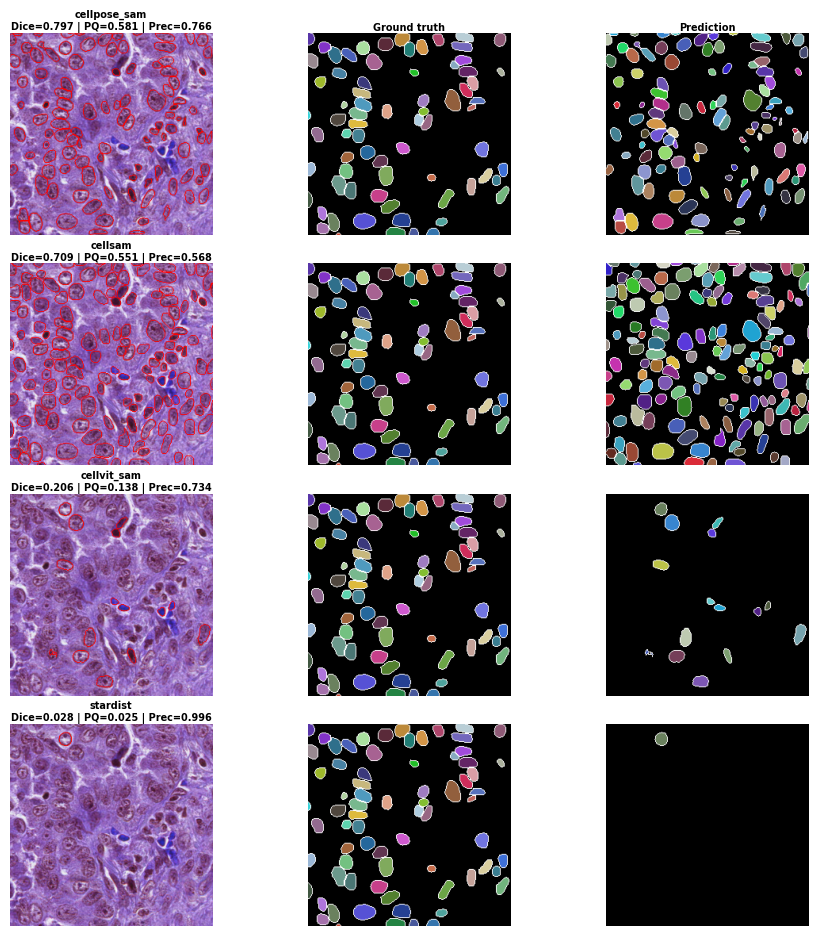

Table row 56 | match_key = 0043_train_0043_TCGA-EJ-5517_prostate.00256x_00256y


/tmp/ipykernel_24432/581661097.py:173: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=(0.0, 0.0, 1.0, 1.0), h_pad=0.15, w_pad=0.05)


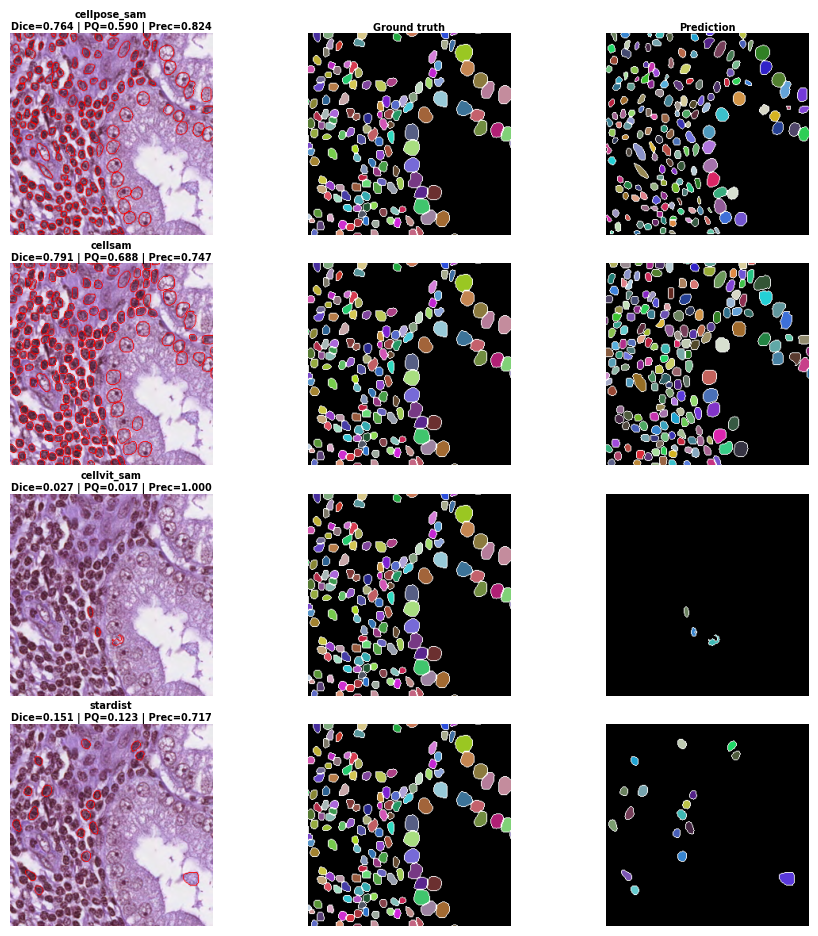

Table row 6 | match_key = 0004_train_0004_TCGA-55-1594_lung.00000x_00256y


/tmp/ipykernel_24432/581661097.py:173: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=(0.0, 0.0, 1.0, 1.0), h_pad=0.15, w_pad=0.05)


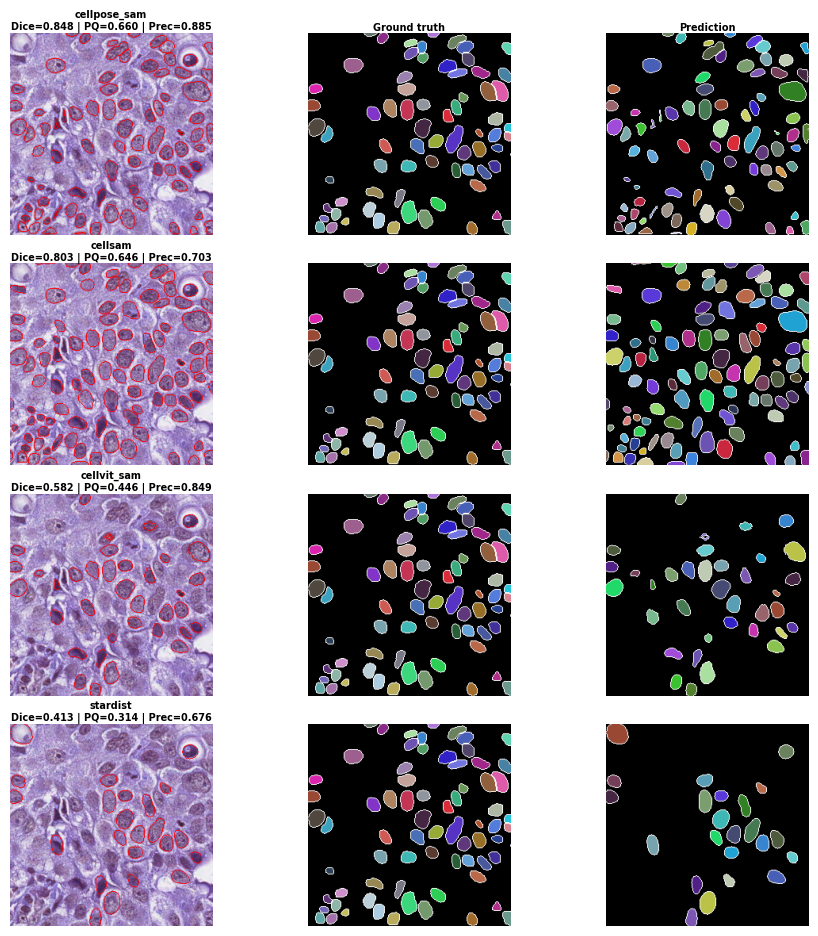

Rendered 3 comparison figure(s).


In [53]:
plot_results = plot_selected_rows(
    selected_rows,
    evaluation_table=evaluation_table,
    prediction_root=PREDICTION_ROOT,
    model_names=DEFAULT_MODEL_ORDER,
    max_models=MAX_MODELS_PER_FIGURE,
    status=DEFAULT_STATUS_FOR_PLOTTING,
    save_directory=SAVE_DIRECTORY if SAVE_FIGURES else None,
    save_dpi=SAVE_DPI,
)

print(f"Rendered {len(plot_results)} comparison figure(s).")